Lazy-PRM-Extionsion and Collision Checks
============

by Eric Schubert and Philipp Meyer

## 1. Introduction

#### Why collision checking is a deciding factor for planning time?

❌ not finished

usual stuff -> tricky math
I think also because we are checking in continuous space -> infinite amout of possible checks -> we have to discretize => will never be perfect
Also we often generate a lot of paths, we check all of those for collisions.

#### What is the idea behind Lazy PRM?

❌ not finished

In the end we only use one path -> for this one we need to check for collisions.
However with other approaches for nodes/edges we check for collisions they are not on the resulting path -> we want to avoid unnecessary collision checks by only checking paths that are assumed to be feasible.
-> minimize collision checks
-> reuse information gathered by queries

### Investigated Lazy PRM variants

### Criteria used for Evaluation

## 2. Analysis of existing implementations

### _buildRoadMap
Predetermine the number of nodes -> place them at random positions
Connect the k nearest neighboring nodes


### _checkForCollisionAndUpdate
check if the node itself is colliding with an obstacle -> if yes remove
for every path between two nodes -> check if the line is colliding with an obstacle -> if yes remove the edge and store the removed edge (so that we won't try to place it again.)

### Edge storation
collidingEdges = we store connections between nodes that collide with obstacles, so that we know they are not possible and we also don't try to add them again in the future

nonCollidingEdges = edges that are possible -> this is not implemented yet, but we probably want to store which edges we already have checked so that we can reuse this knowledge later on.


### Parameters
initialRoadmapSize = number of Nodes of the first roadmap

updateRoadmapSize = number of nodes to add if there is no connection from start to end

kNearest = number of nodes to connect to during setup

maxIterations = fail-safe limit that dictates how many times the algorithm is allowed to add new nodes and retry finding a path before giving up, preventing an infinite loop when no solution exists.


### Visualization in IPVISLazyPRM.py
draw obstacles and graph
draw all connected components, emphasize the largest one
draw collidingEdges in red
nonCollidingEdges in yellow
StartNode in Green, goal in Red
Solution Path in green


### Limits of the equally distributed node-enhancement phase
❌ not finished

the points are sampled randomly -> so not necessary in the area where we would need them. But because they are random we are also not committing to a wrong region or stuff like that.

## 4. Comparison of LazyPRM Node Checking vs. Early Node Checking

❌ not finished

how can we make qualified assessments about the performance (because the points are always just sampled randomly -> can do both good or bad) -> do we really have to run them for 50 times or something? Or is a theoretical investigation sufficient -> I think so because in a later exercise we should run them 30 times.

The name EarlyPRM probably has to be changed

|                | LazyPRM | EarlyPRM |
|:---------------|:--------|:---------|
| Good when      | - Sparse environment<br>- Few collisions | - Dense environment<br>- Many collisions |
| Bad when       | - we risk planning paths on nodes and edges that are invalid | - if there aren't many obstacles we are too cautious |


In dense environments EarlyPRM helps us with having to try many paths that work anyway, because we before identify that the nodes are invalid. But if there are few or no obstacles one could just go without the caution EarlyPRM provides.

In [11]:
from IPEarlyPRM import EarlyPRM
from IPLazyPRM import LazyPRM
from IPVISLazyPRM import lazyPRMVisualize
import matplotlib.pylab as plt
import IPTestSuite as ts

from IPPerfMonitor import IPPerfMonitor


Benchmark: Trap (Level 2)


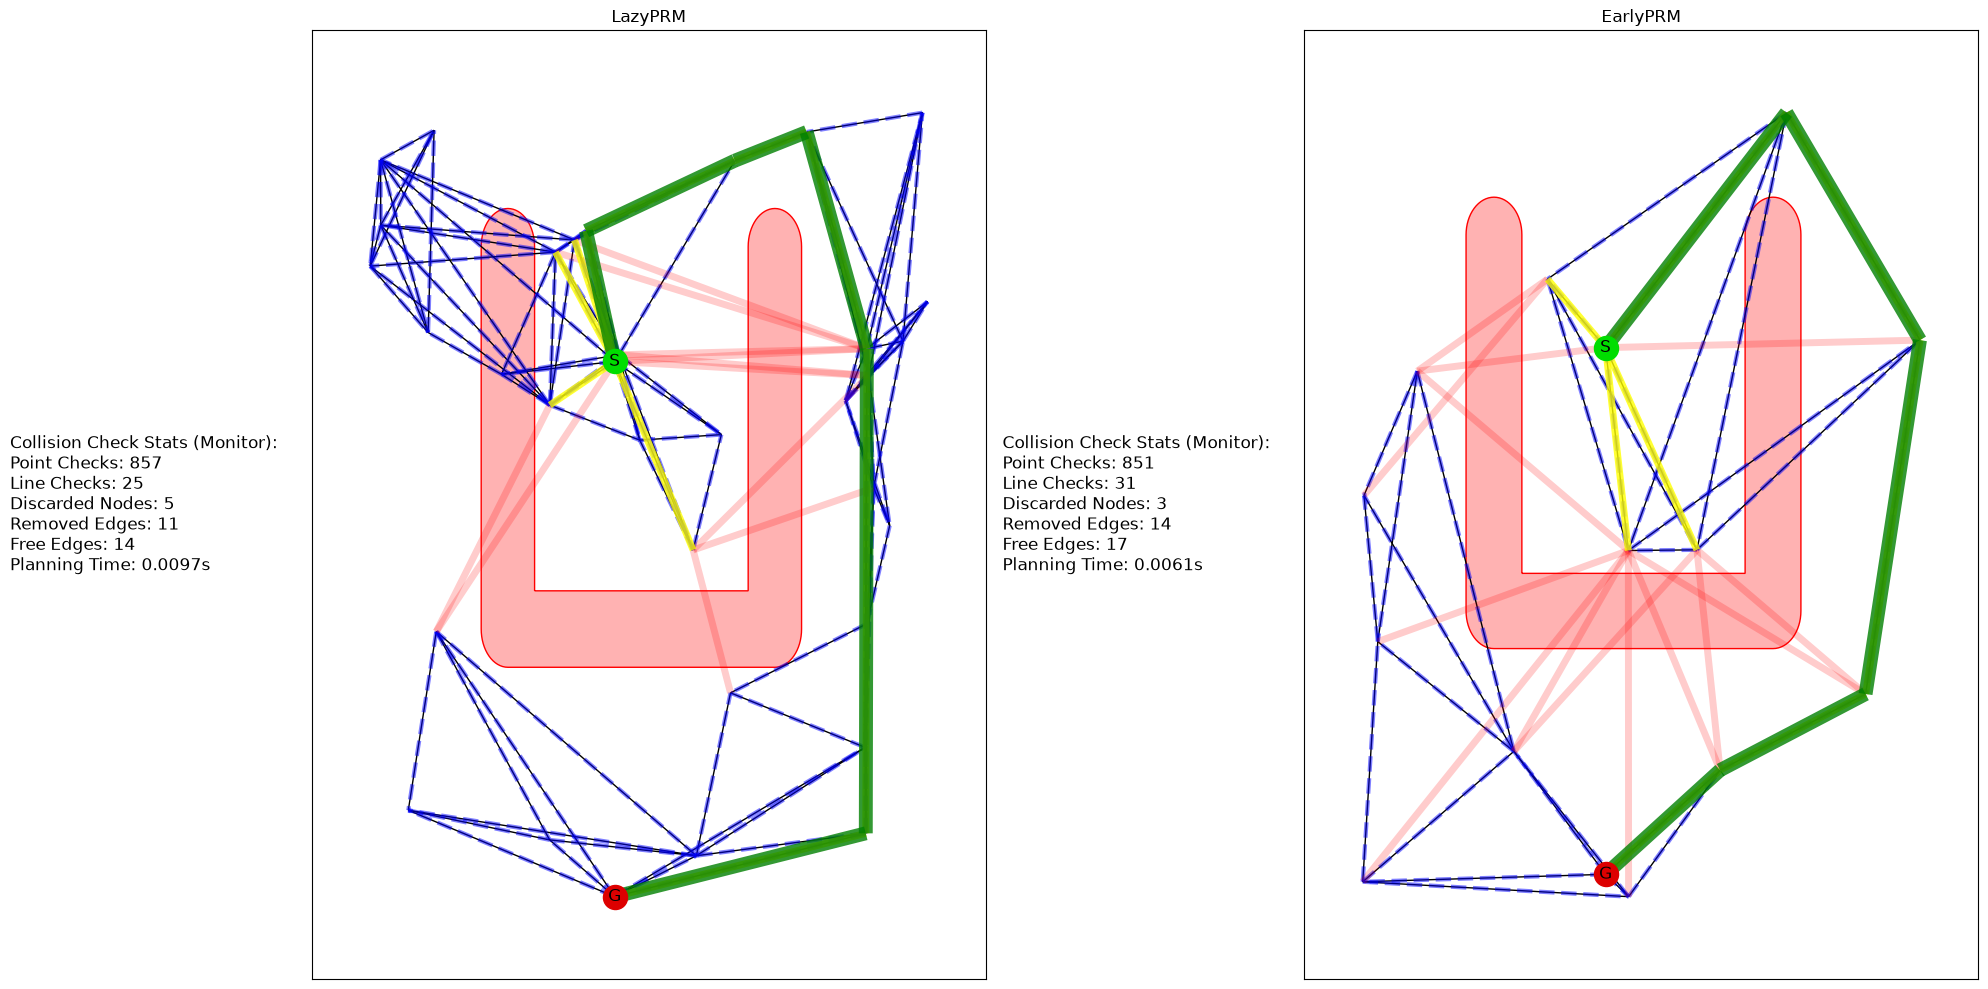

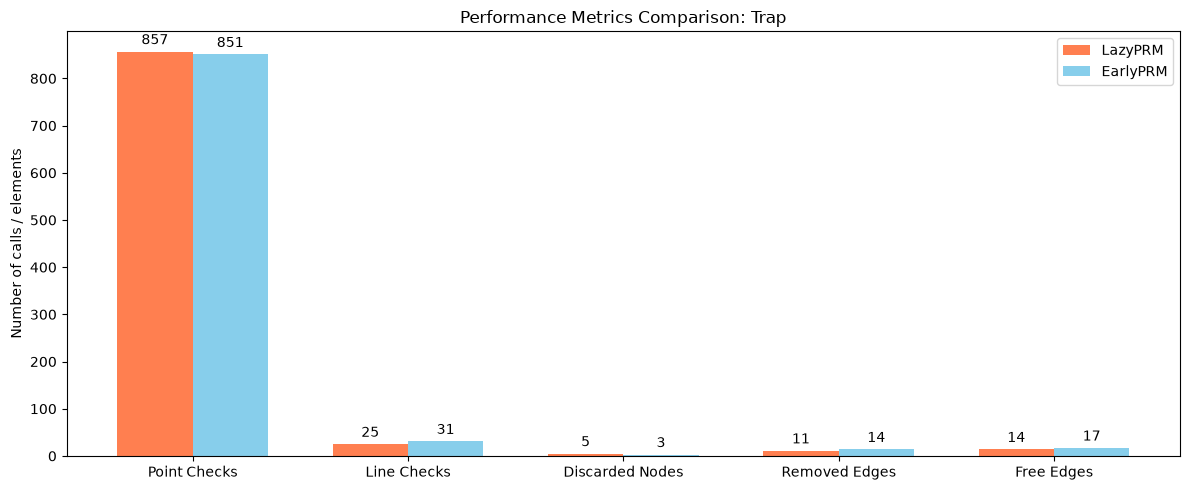


Benchmark: Bottleneck (Level 2)


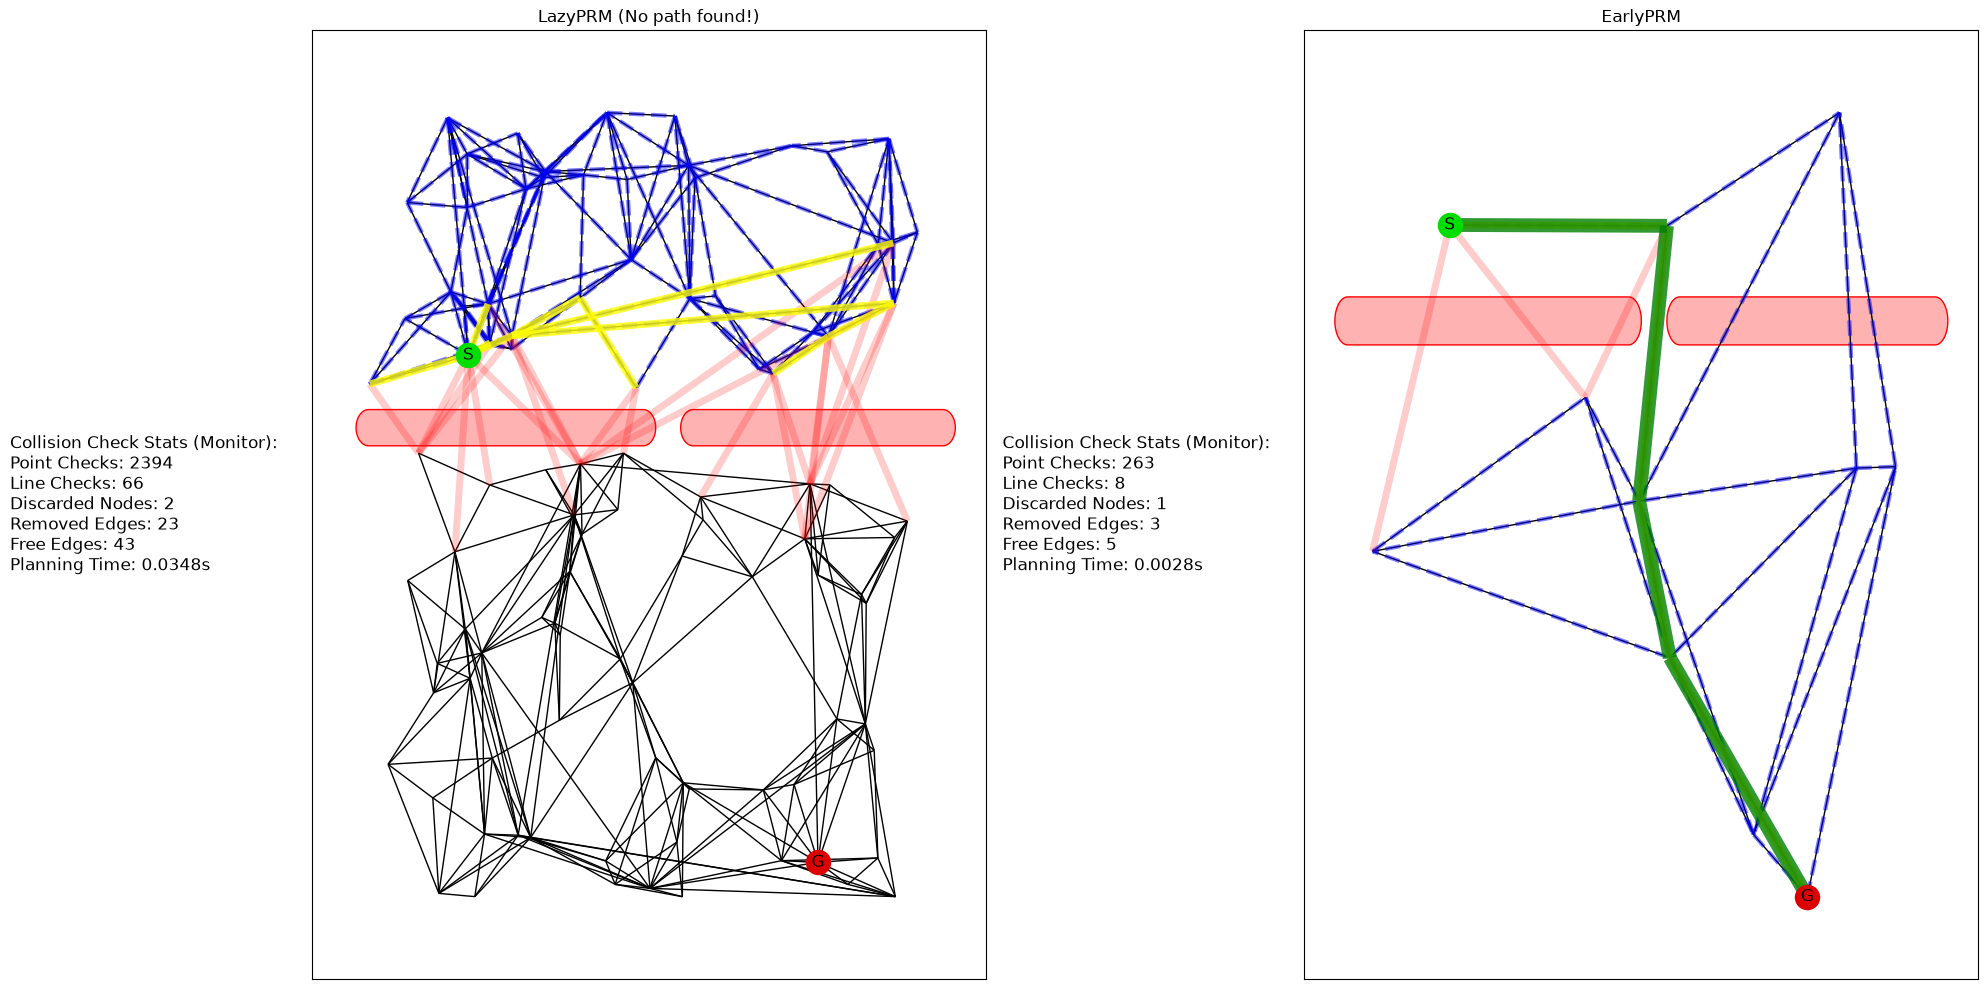

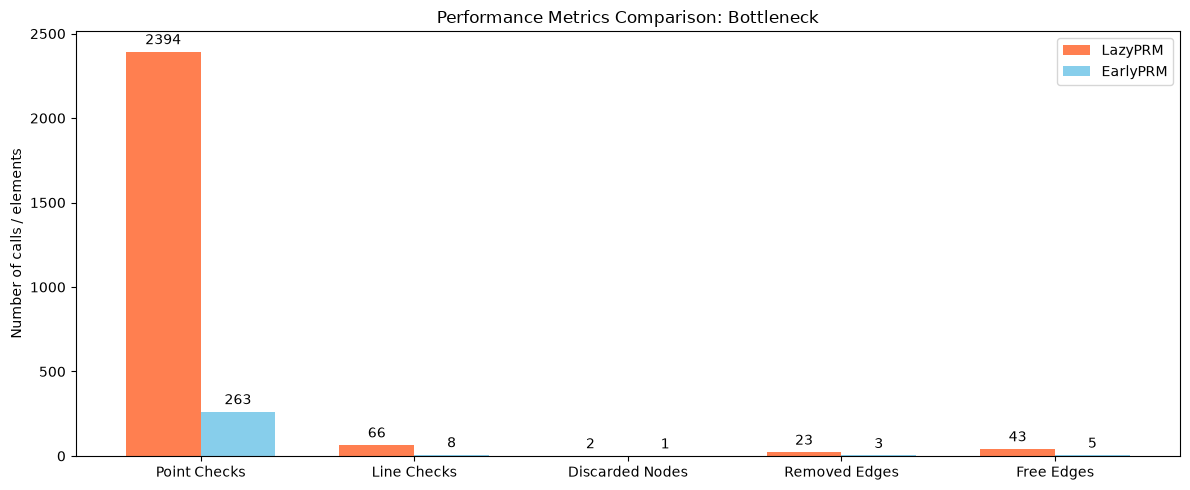


Benchmark: Fat bottleneck (Level 2)


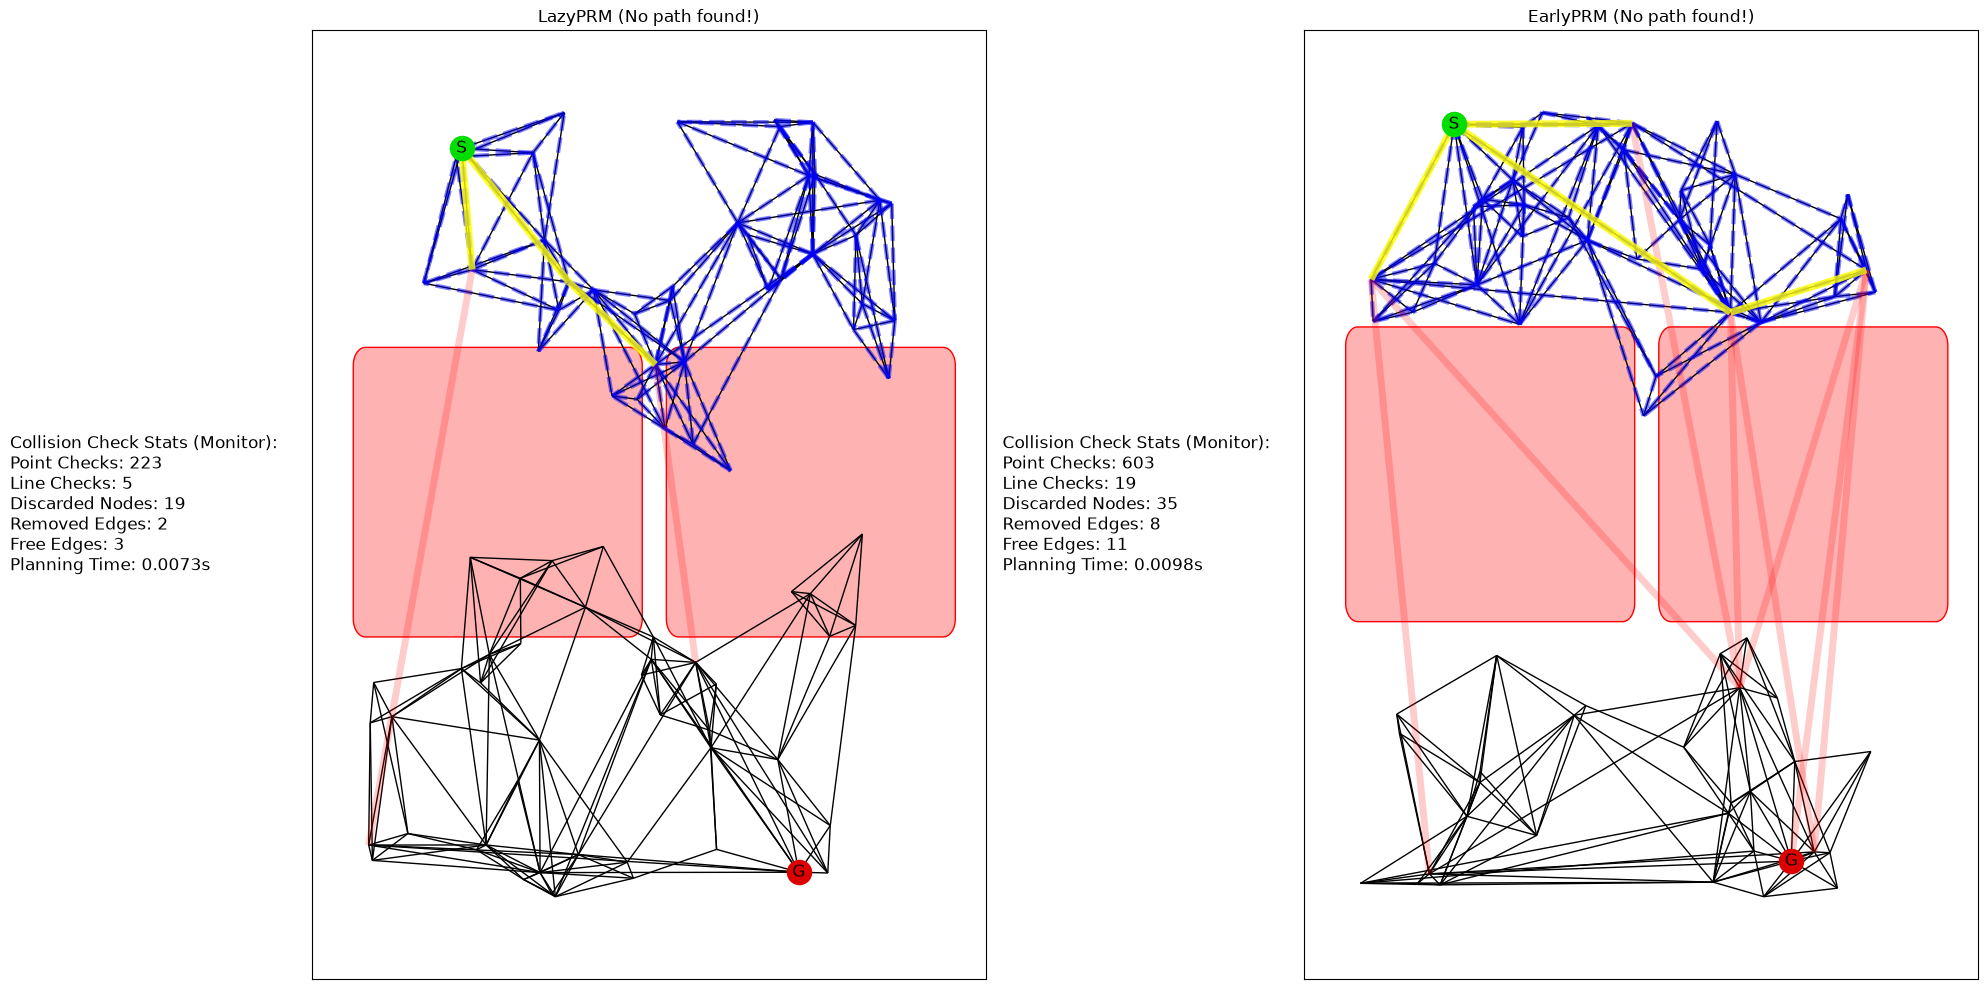

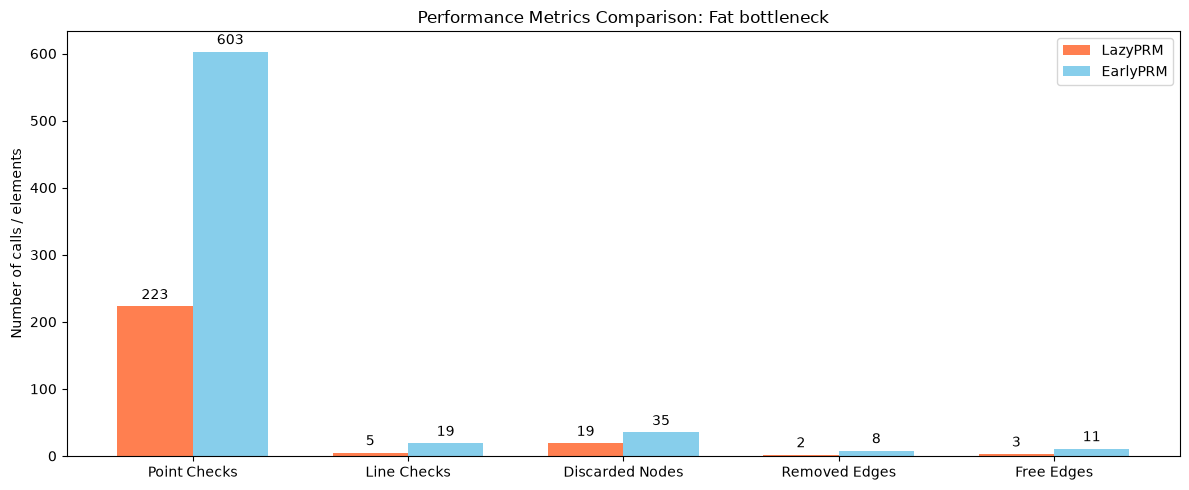


Benchmark: MyField (Level 2)


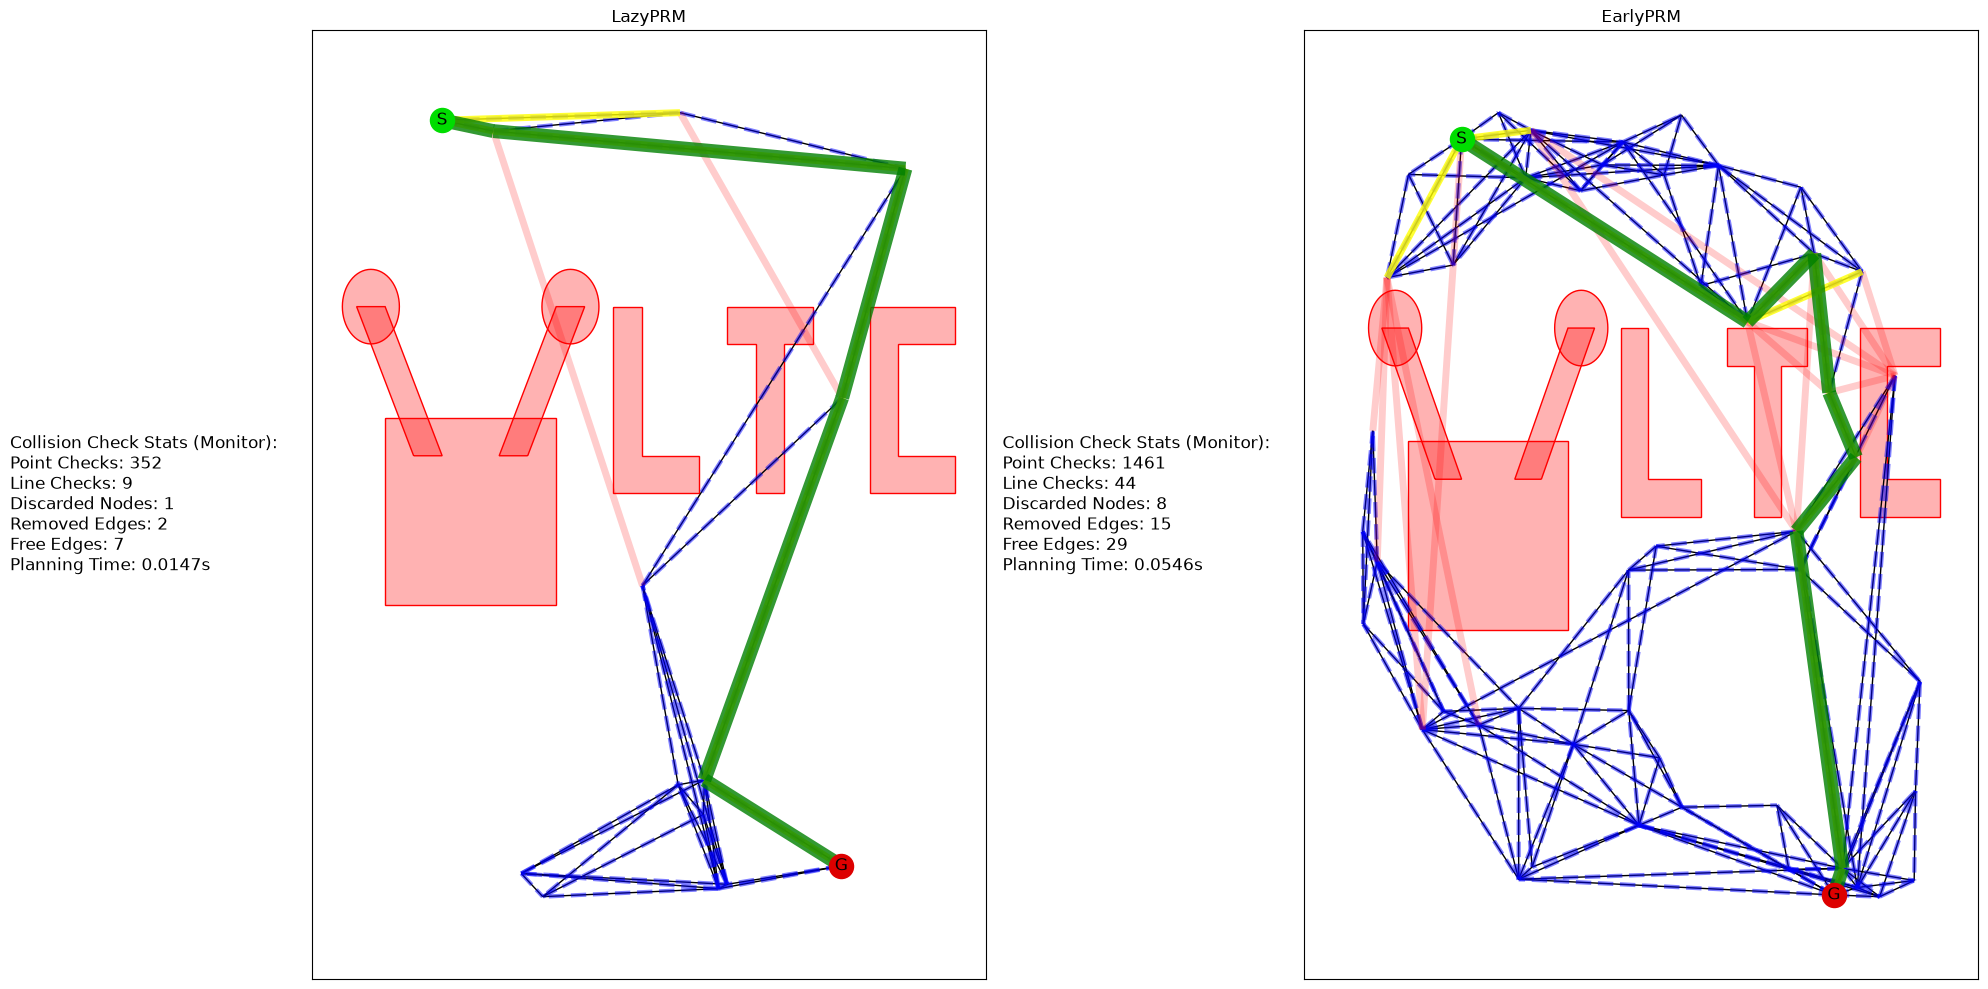

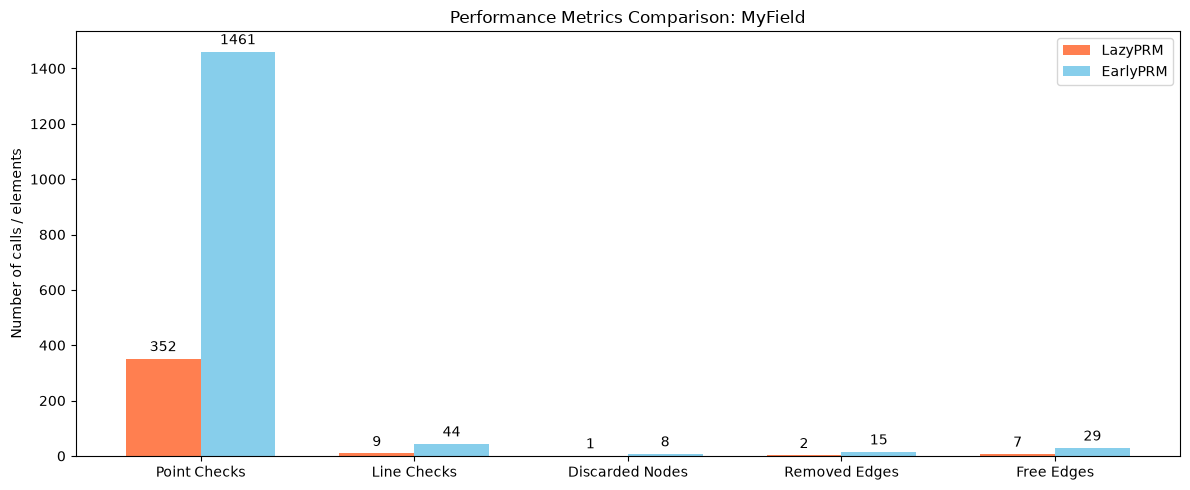


Benchmark: Zigzag Traps (Level 2)


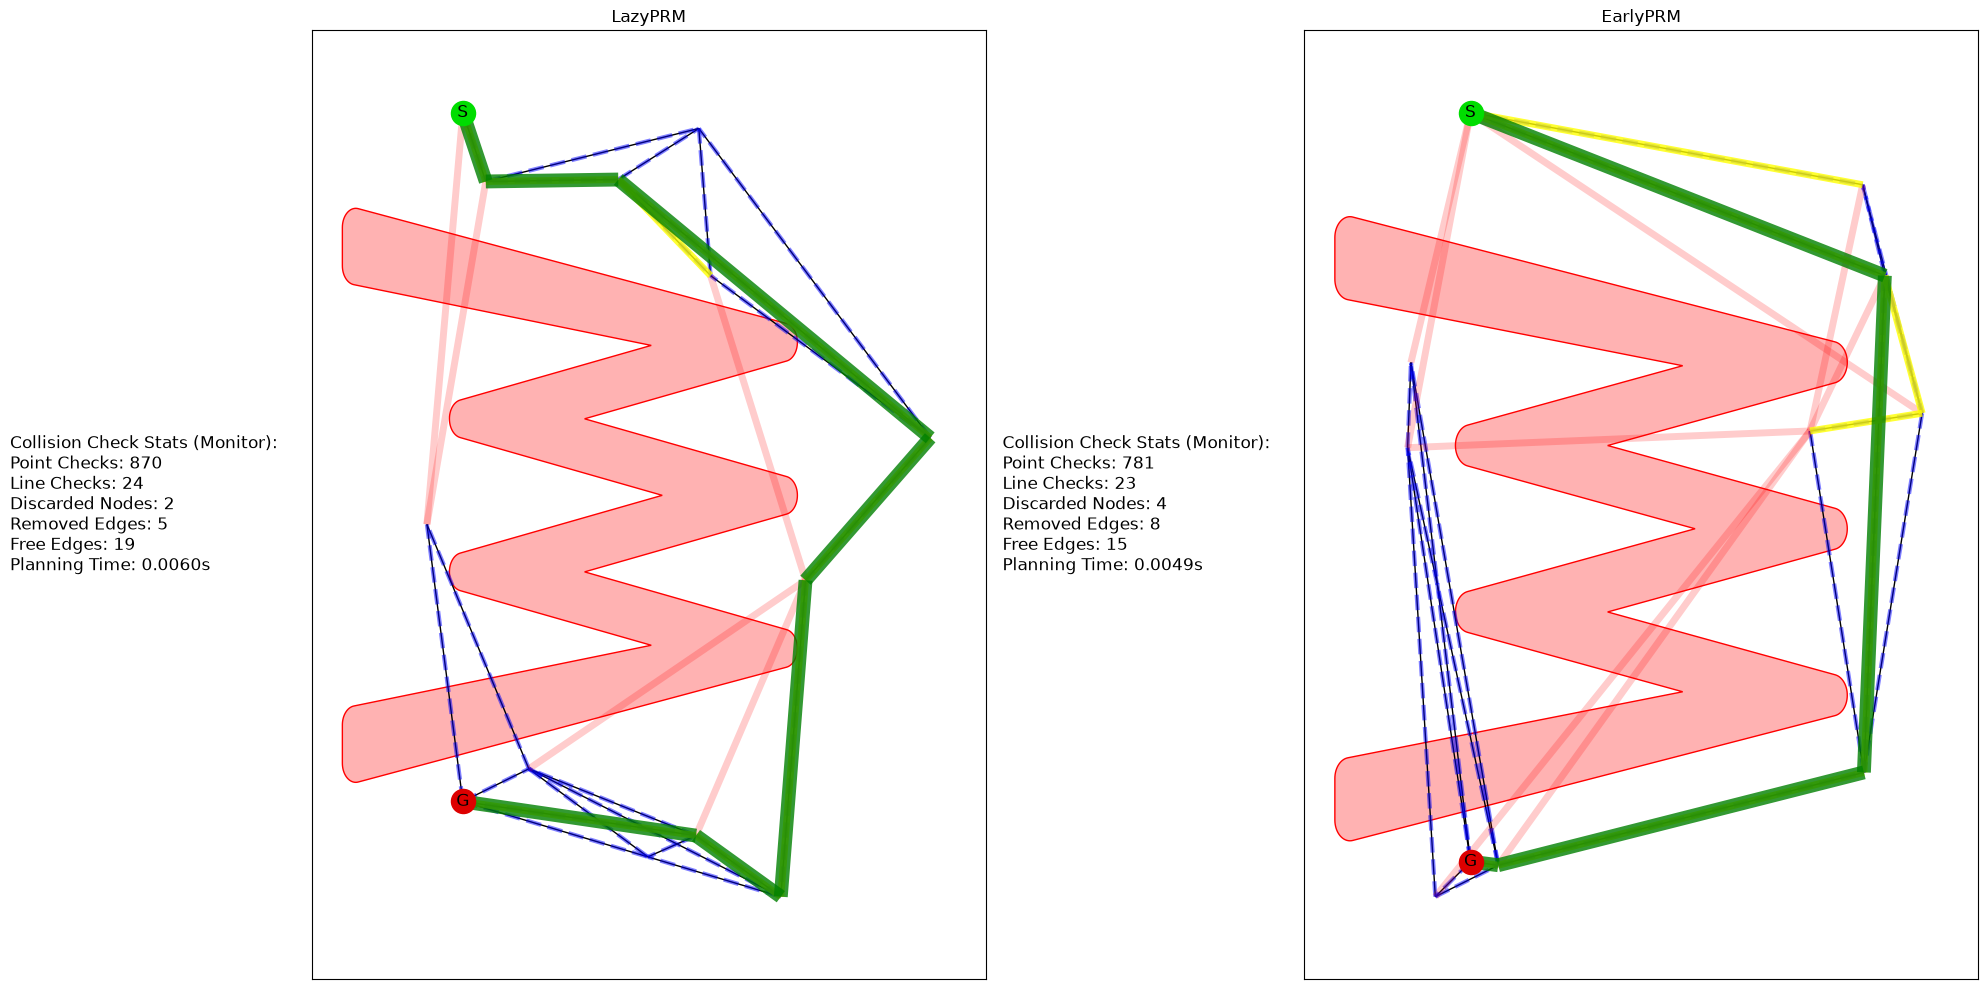

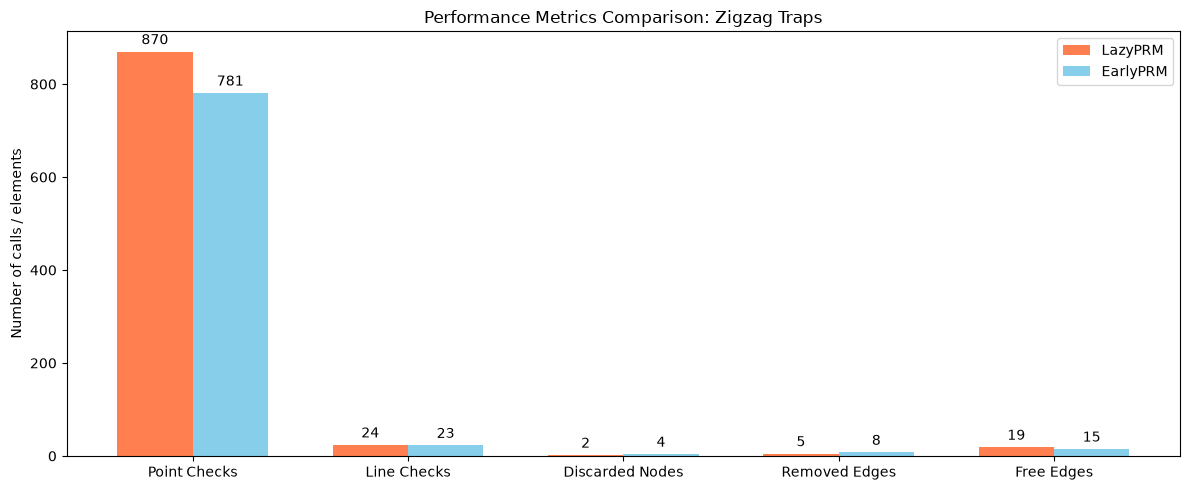


Benchmark: Empty Field (Level 2)


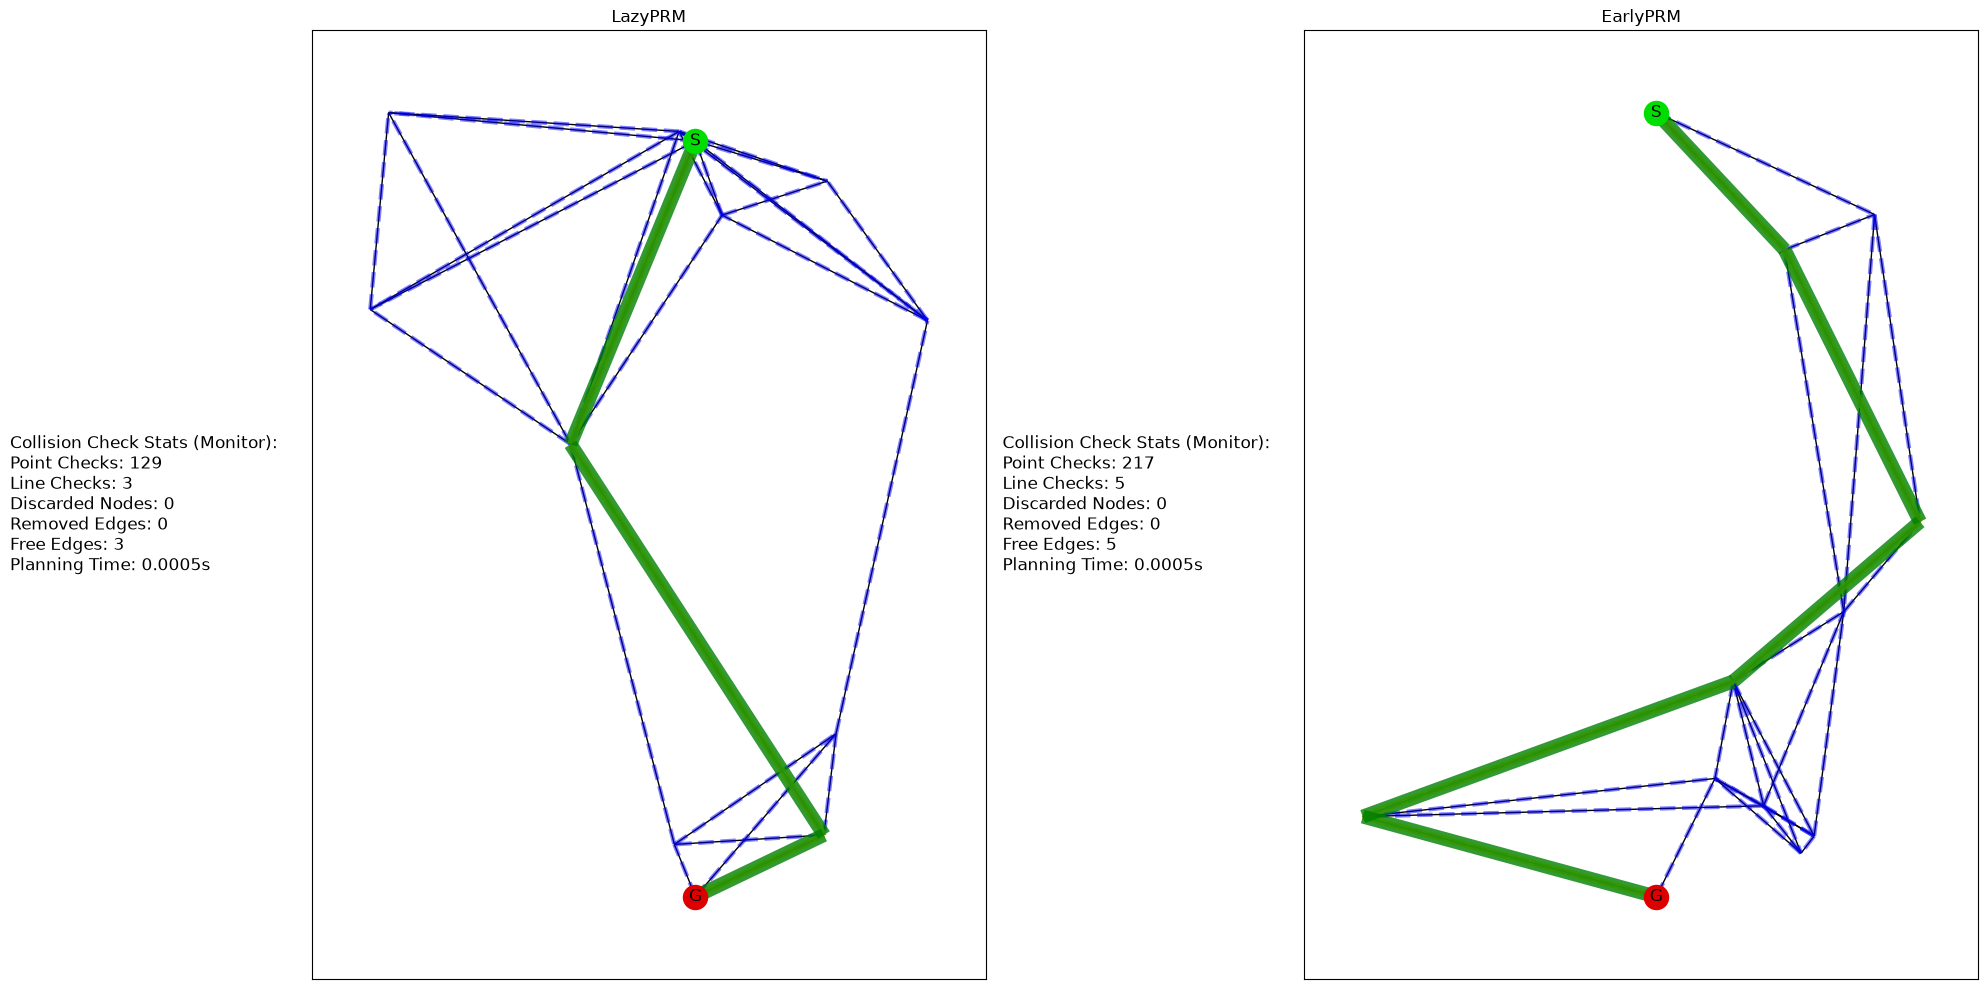

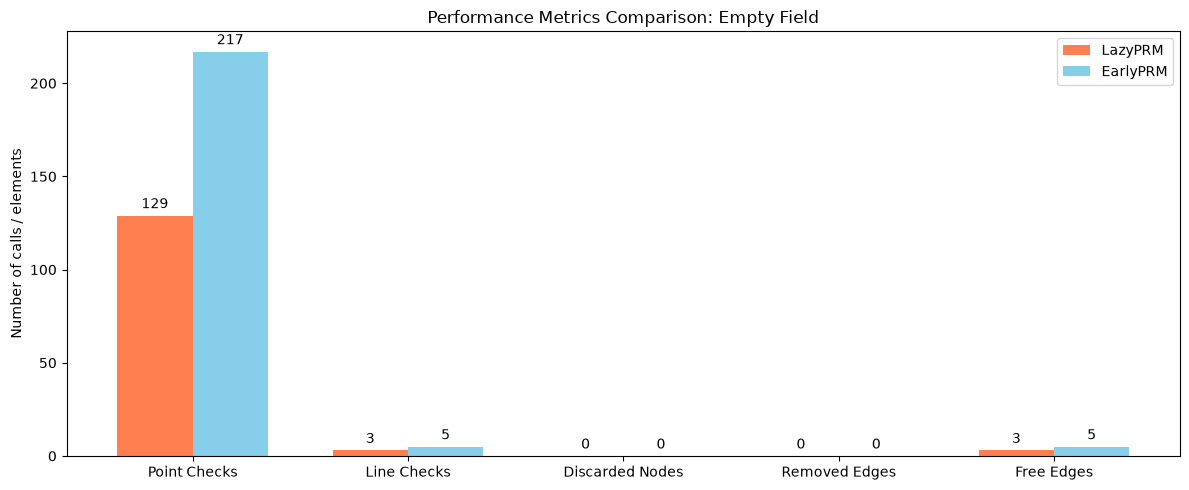


Benchmark: Clutter Forest (Level 2)


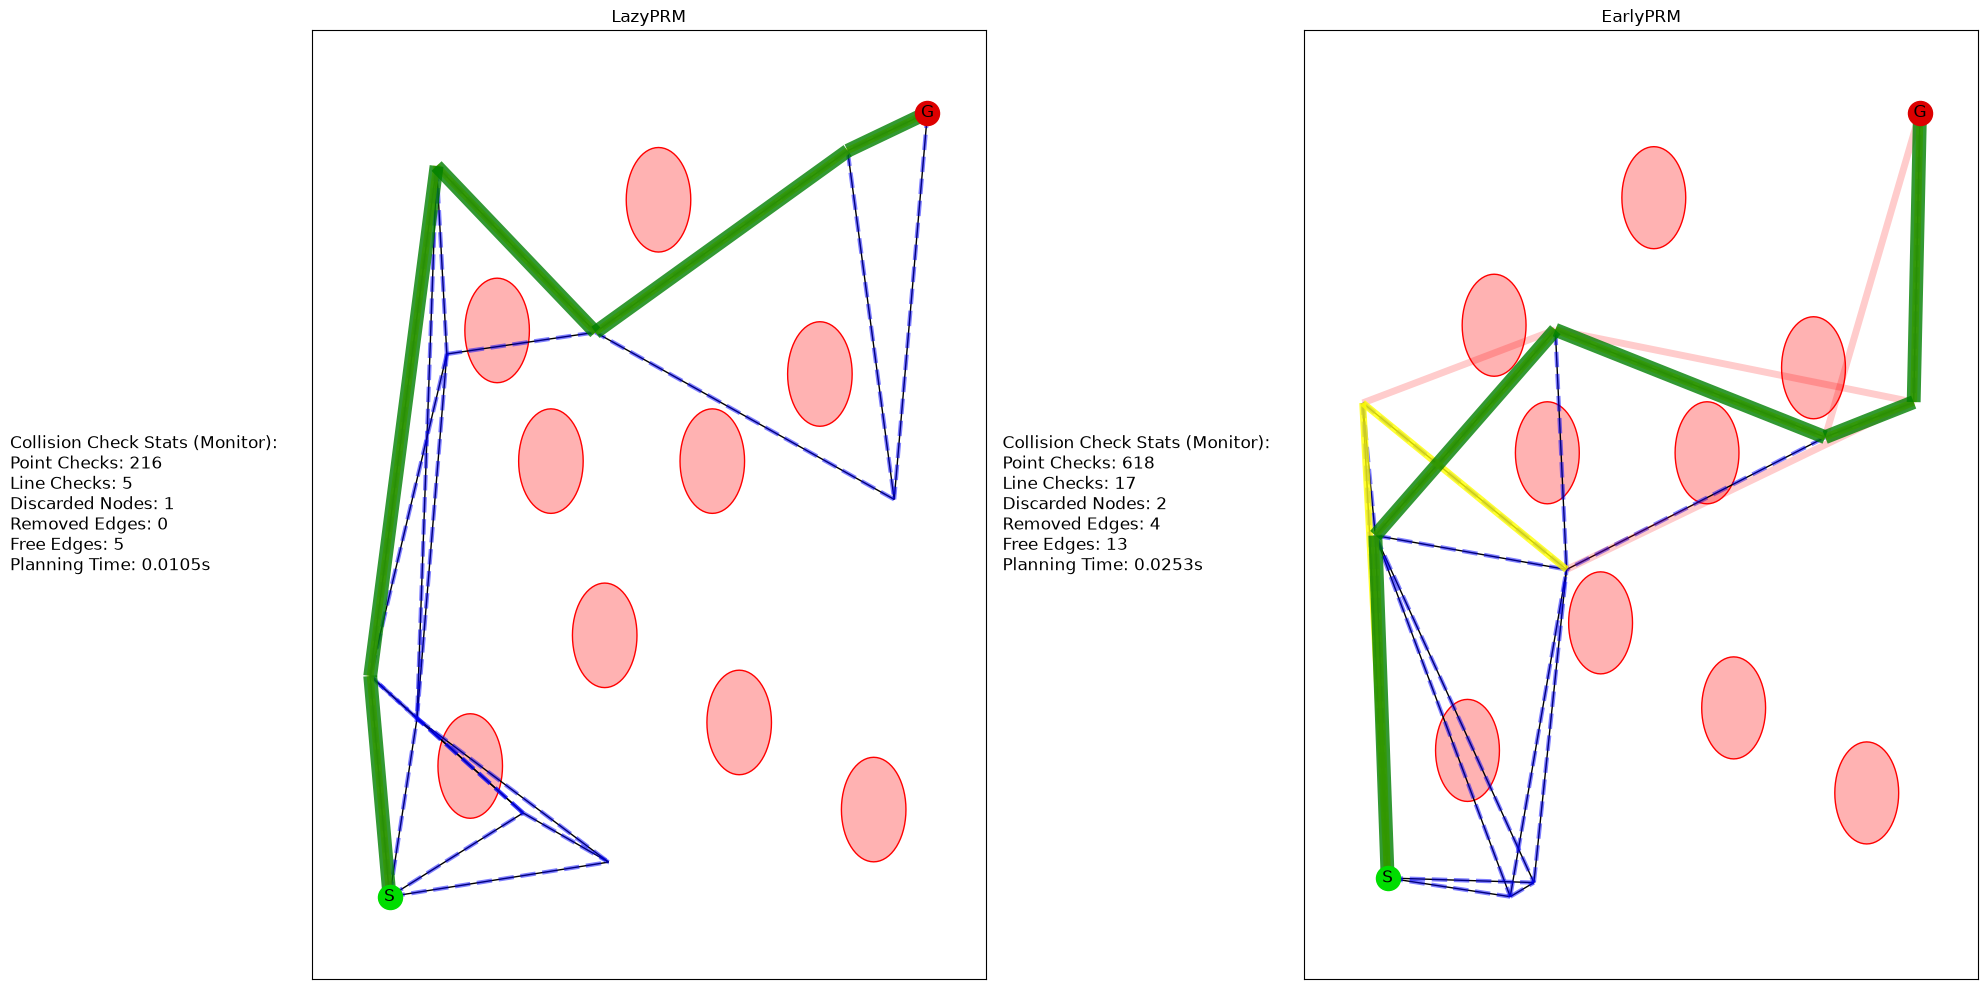

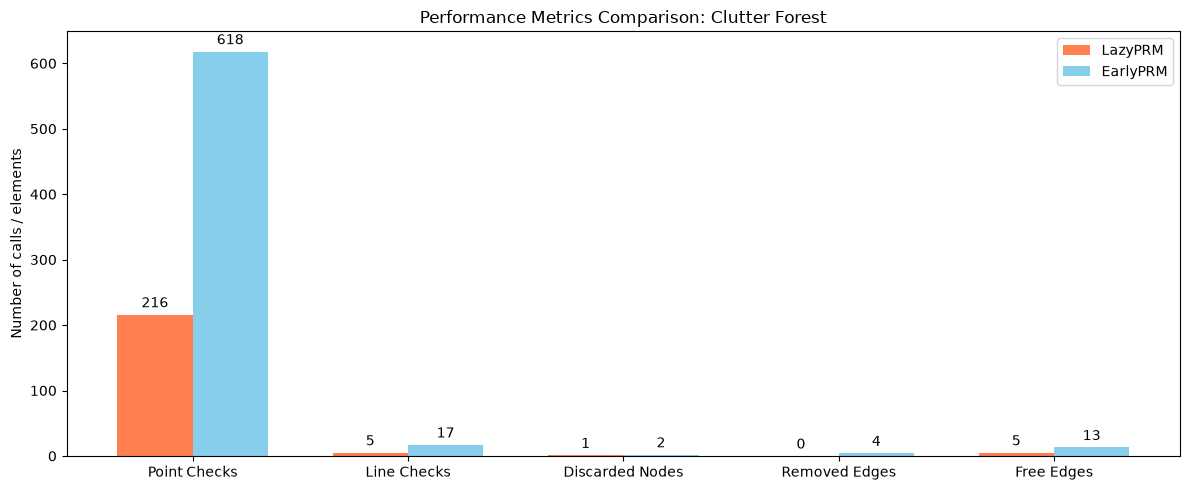


Benchmark: Dual Path (Level 2)


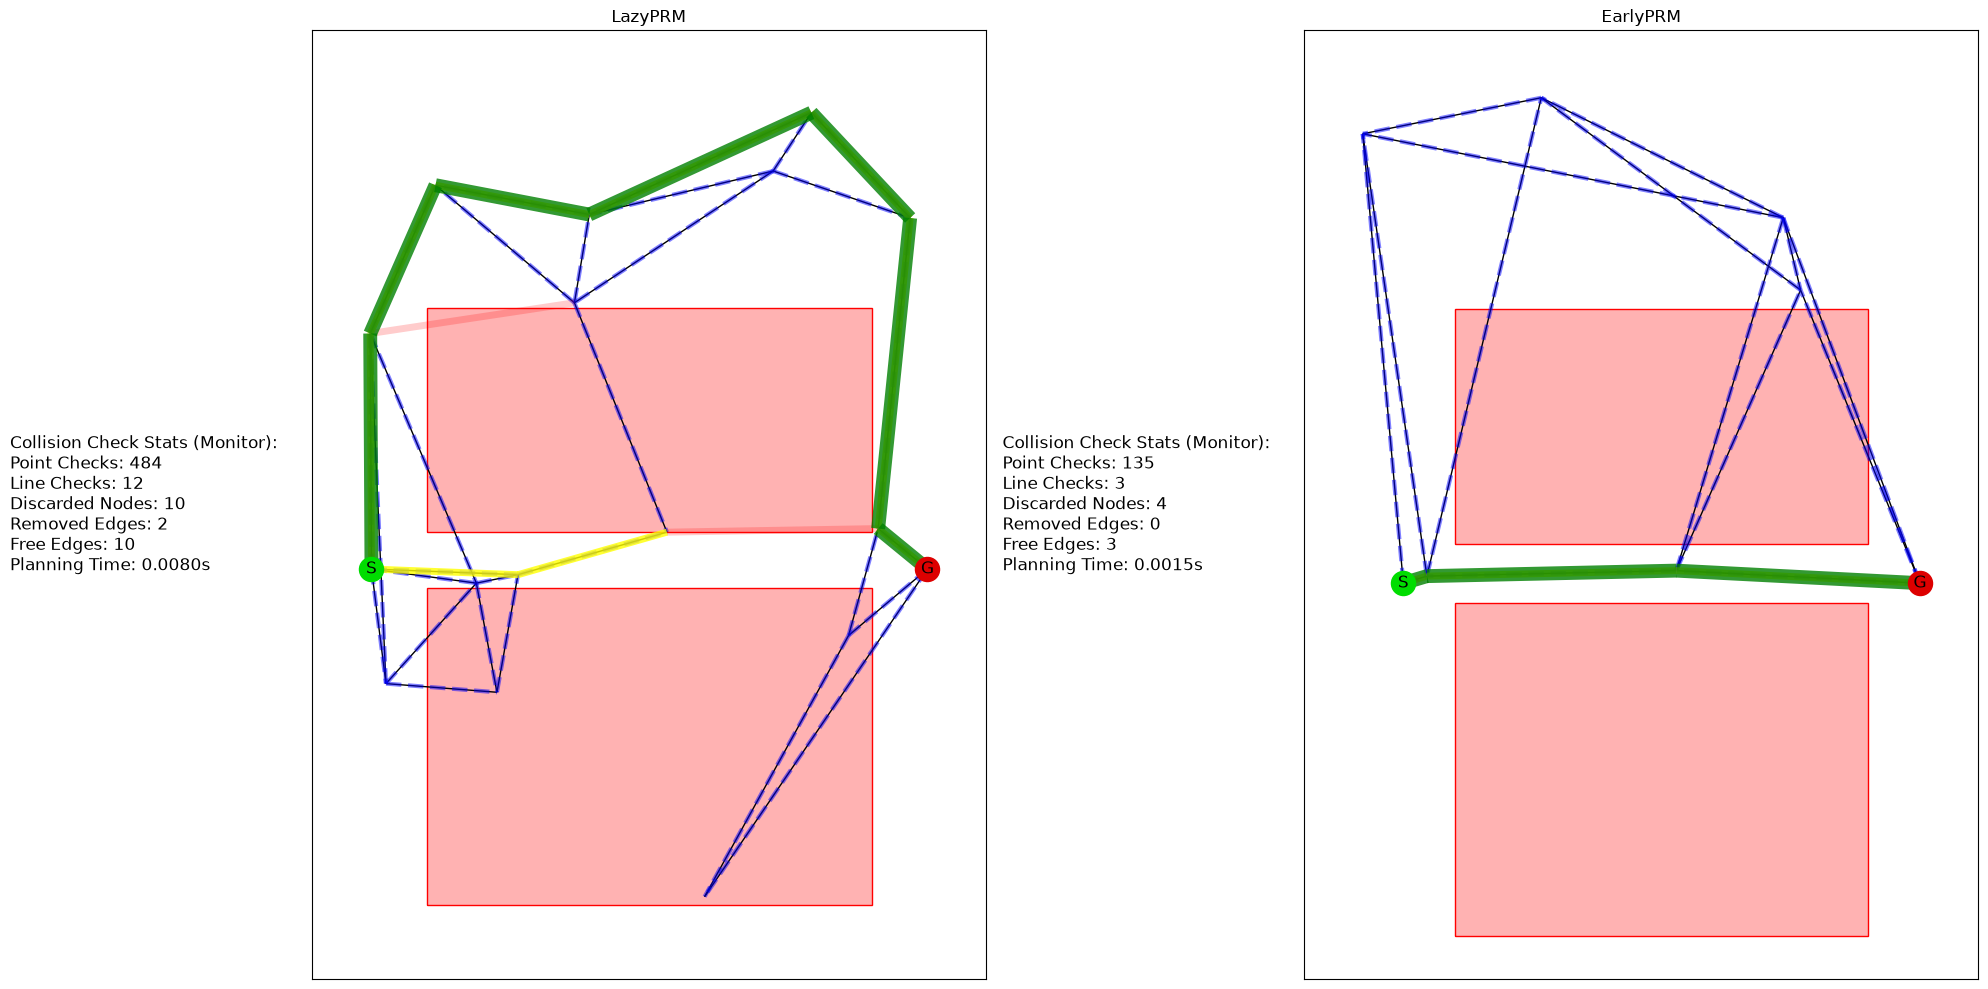

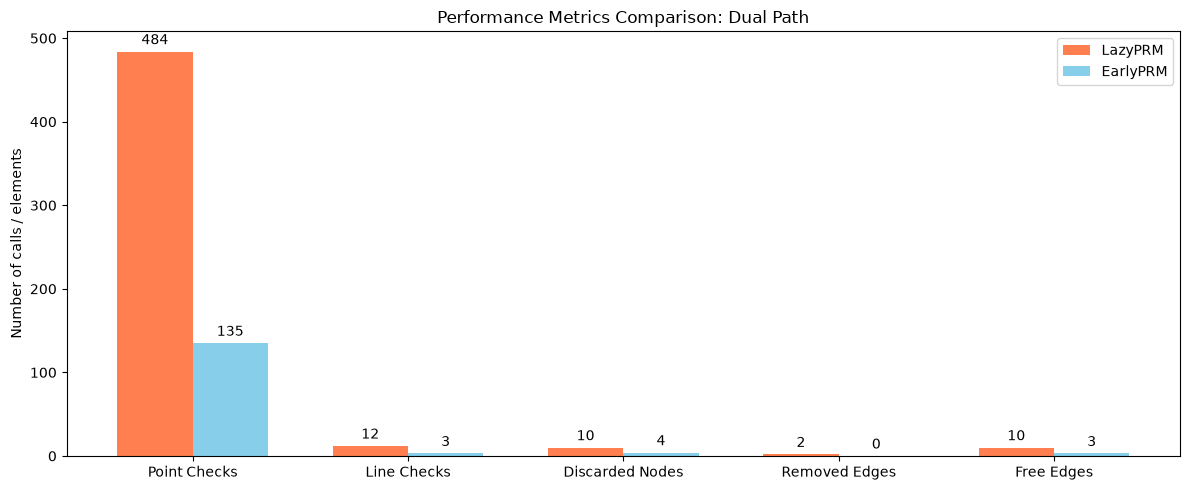


Benchmark: Nested Trap (Level 2)


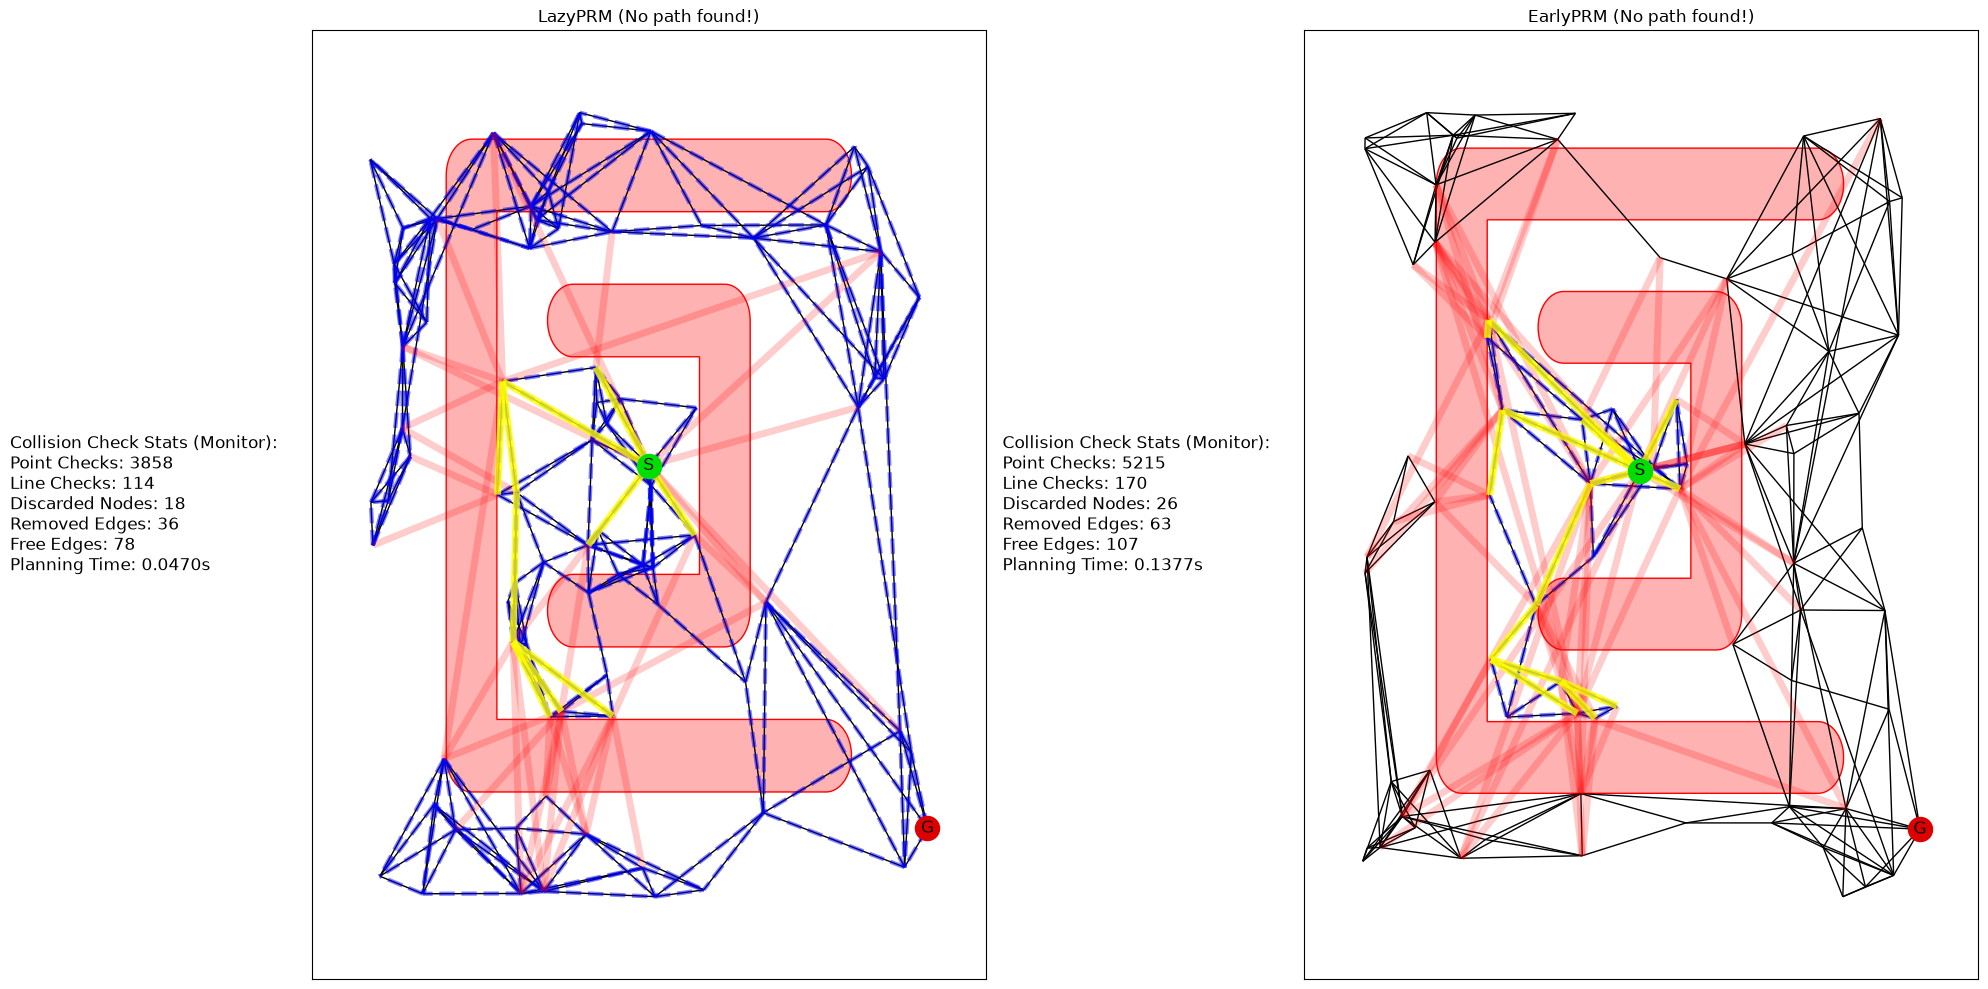

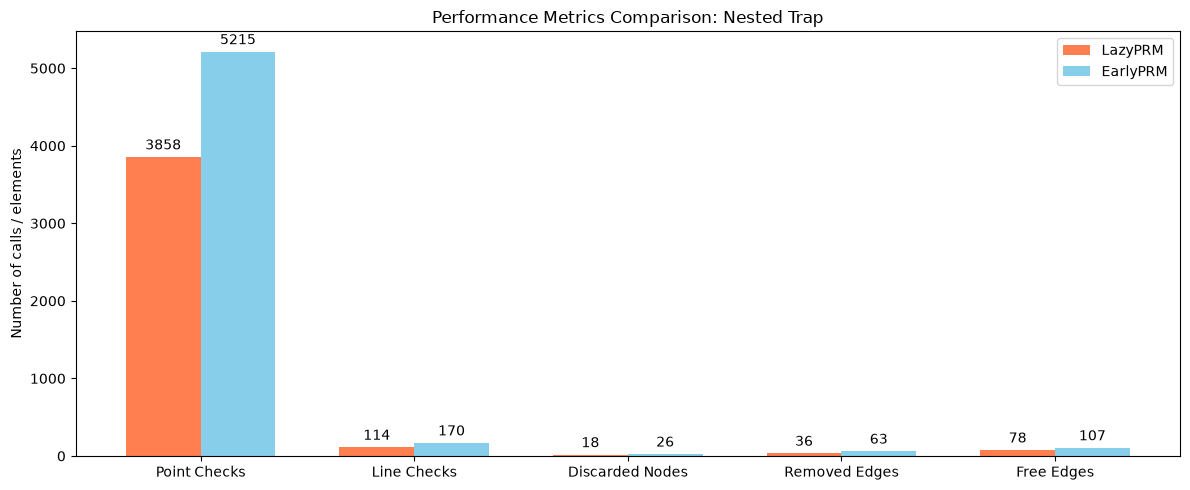

In [12]:
import numpy as np
import matplotlib.pyplot as plt

lazyConfig = dict()
lazyConfig["initialRoadmapSize"] = 10
lazyConfig["updateRoadmapSize"] = 3
lazyConfig["kNearest"] = 5
lazyConfig["maxIterations"] = 30

for benchmark in ts.benchList:
    print(f"\n{'='*60}\nBenchmark: {benchmark.name} (Level {benchmark.level})\n{'='*60}")

    # Create figure for both roadmaps
    fig_graphs = plt.figure(figsize=(20, 10))
    ax1 = fig_graphs.add_subplot(1, 2, 1)
    ax2 = fig_graphs.add_subplot(1, 2, 2)

    # Run LazyPRM
    IPPerfMonitor.clearData()
    try:
        vis_lazy = LazyPRM(benchmark.collisionChecker)
        solution_lazy = vis_lazy.planPath(
            benchmark.startList,
            benchmark.goalList,
            lazyConfig,
        )

        ax1.set_title("LazyPRM" + (" (No path found!)" if not solution_lazy else ""))

        # Make the left axis active
        plt.sca(ax1)
        lazyPRMVisualize(vis_lazy, solution_lazy, ax=ax1, nodeSize=50)

        df_lazy = IPPerfMonitor.dataFrame()
        p_checks_lazy = len(df_lazy[df_lazy["name"] == "pointInCollision"]) if not df_lazy.empty else 0
        l_checks_lazy = len(df_lazy[df_lazy["name"] == "lineInCollision"]) if not df_lazy.empty else 0
        rem_nodes_lazy = len(vis_lazy.collidingNodes)
        rem_edges_lazy = len(vis_lazy.collidingEdges)
        free_edges_lazy = len(vis_lazy.nonCollidingEdges)

    except Exception as e:
        print("ERROR LazyPRM:", benchmark.name, e)
        plt.close(fig_graphs)
        continue

    # Run EarlyPRM
    IPPerfMonitor.clearData()
    try:
        vis_early = EarlyPRM(benchmark.collisionChecker)
        solution_early = vis_early.planPath(
            benchmark.startList,
            benchmark.goalList,
            lazyConfig,
        )

        ax2.set_title("EarlyPRM" + (" (No path found!)" if not solution_early else ""))

        # Make the right axis active
        plt.sca(ax2)
        lazyPRMVisualize(vis_early, solution_early, ax=ax2, nodeSize=50)

        df_early = IPPerfMonitor.dataFrame()
        p_checks_early = len(df_early[df_early["name"] == "pointInCollision"]) if not df_early.empty else 0
        l_checks_early = len(df_early[df_early["name"] == "lineInCollision"]) if not df_early.empty else 0
        rem_nodes_early = len(vis_early.collidingNodes)
        rem_edges_early = len(vis_early.collidingEdges)
        free_edges_early = len(vis_early.nonCollidingEdges)

    except Exception as e:
        print("ERROR EarlyPRM:", benchmark.name, e)
        plt.close(fig_graphs)
        continue

    plt.tight_layout()
    plt.show()

    # Compare performance metrics
    labels = [
        "Point Checks",
        "Line Checks",
        "Discarded Nodes",
        "Removed Edges",
        "Free Edges",
    ]

    lazy_stats = [
        p_checks_lazy,
        l_checks_lazy,
        rem_nodes_lazy,
        rem_edges_lazy,
        free_edges_lazy,
    ]

    early_stats = [
        p_checks_early,
        l_checks_early,
        rem_nodes_early,
        rem_edges_early,
        free_edges_early,
    ]

    x = np.arange(len(labels))
    width = 0.35

    fig_stats, ax_stats = plt.subplots(figsize=(12, 5))

    ax_stats.bar(x - width / 2, lazy_stats, width, label="LazyPRM", color="coral")
    ax_stats.bar(x + width / 2, early_stats, width, label="EarlyPRM", color="skyblue")

    ax_stats.set_ylabel("Number of calls / elements")
    ax_stats.set_title(f"Performance Metrics Comparison: {benchmark.name}")
    ax_stats.set_xticks(x)
    ax_stats.set_xticklabels(labels)
    ax_stats.legend()

    offset = max(lazy_stats + early_stats) * 0.01

    for i, value in enumerate(lazy_stats):
        ax_stats.text(
            i - width / 2,
            value + offset,
            str(value),
            ha="center",
            va="bottom",
            fontsize=10,
        )

    for i, value in enumerate(early_stats):
        ax_stats.text(
            i + width / 2,
            value + offset,
            str(value),
            ha="center",
            va="bottom",
            fontsize=10,
        )

    plt.tight_layout()
    plt.show()

## 7. Validation on simple Example:

❌ not finished

### LazyPRM outperforms

LazyPRM is better on an empty testbench where we sample a lot of nodes.


### EarlyPRM outperforms
EarlyPRM with start top left and goal bottom right and huge square in the middle -> a lot of points are going to be sampled in the sqaure and LazyPRM is often to try them and then realize they are not working and with EarlyPRM we will never even try them


### Targeted Node Enhancement outperforms
node sampling only possible in tiny area -> with identically distributed sampling we would have mostly invalid points.